In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
df = pd.read_csv("updated_dataset.csv")

In [29]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [30]:
df.shape

(25480, 12)

In [31]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25450.000000
mean,5667.043210,1979.409929,74461.687268
std,22877.928848,42.366929,52798.258836
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34056.782500
50%,2109.000000,1997.000000,70387.810000
75%,3504.000000,2005.000000,107709.092500
max,602069.000000,2016.000000,319210.270000


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25470 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25450 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [33]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print("we have {} numerical features : {}".format(len(numeric_features), numeric_features))
print("we have {} categorical features : {}".format(len(categorical_features), categorical_features))

we have 3 numerical features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']
we have 9 categorical features : ['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


In [34]:
for c in categorical_features:
    print(df[c].value_counts(normalize=True) * 100)
    print("\n")

case_id
EZYV25480    0.003925
EZYV01       0.003925
EZYV02       0.003925
EZYV03       0.003925
EZYV04       0.003925
               ...   
EZYV12       0.003925
EZYV13       0.003925
EZYV14       0.003925
EZYV15       0.003925
EZYV16       0.003925
Name: proportion, Length: 25480, dtype: float64


continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64


education_of_employee
Bachelor's     40.227719
Master's       37.781704
High School    13.427562
Doctorate       8.563015
Name: proportion, dtype: float64


has_job_experience
Y    58.092622
N    41.907378
Name: proportion, dtype: float64


requires_job_training
N    88.402669
Y    11.597331
Name: proportion, dtype: float64


region_of_employment
Northeast    28.237834
South        27.539246
West         25.847724
Midwest      16.903454
Island        1.471743
Name: proportion, dtype: floa

data is imbalanced

In [ ]:
'''
1) ~67% applications are certified → dataset is slightly imbalanced but still usable for ML prediction.
2) Most applicants are from Asia (~66%) → dataset is heavily dominated by Asian applicants, which may influence model patterns.
3) Bachelor’s and Master’s dominate → higher education is common among applicants and may positively affect approval chances.
4) ~58% applicants have work experience → experience likely plays an important role in visa certification.
5) ~88% jobs do not require training → employers prefer candidates who are already skilled.
6) Most jobs are in Northeast, South, and West regions → employment demand is concentrated in these areas.
7) ~90% wages are yearly-based → annual salary is the standard payment structure in this dataset.
8) ~89% positions are full-time → visa sponsorship is mostly associated with stable full-time jobs.
9) case_id should be removed → it is unique for every row and has no predictive value for ML models.
10) Education, experience, wage, and full-time status may strongly affect approval → these features directly relate to applicant qualification and job stability.'''

Univariate Analysis

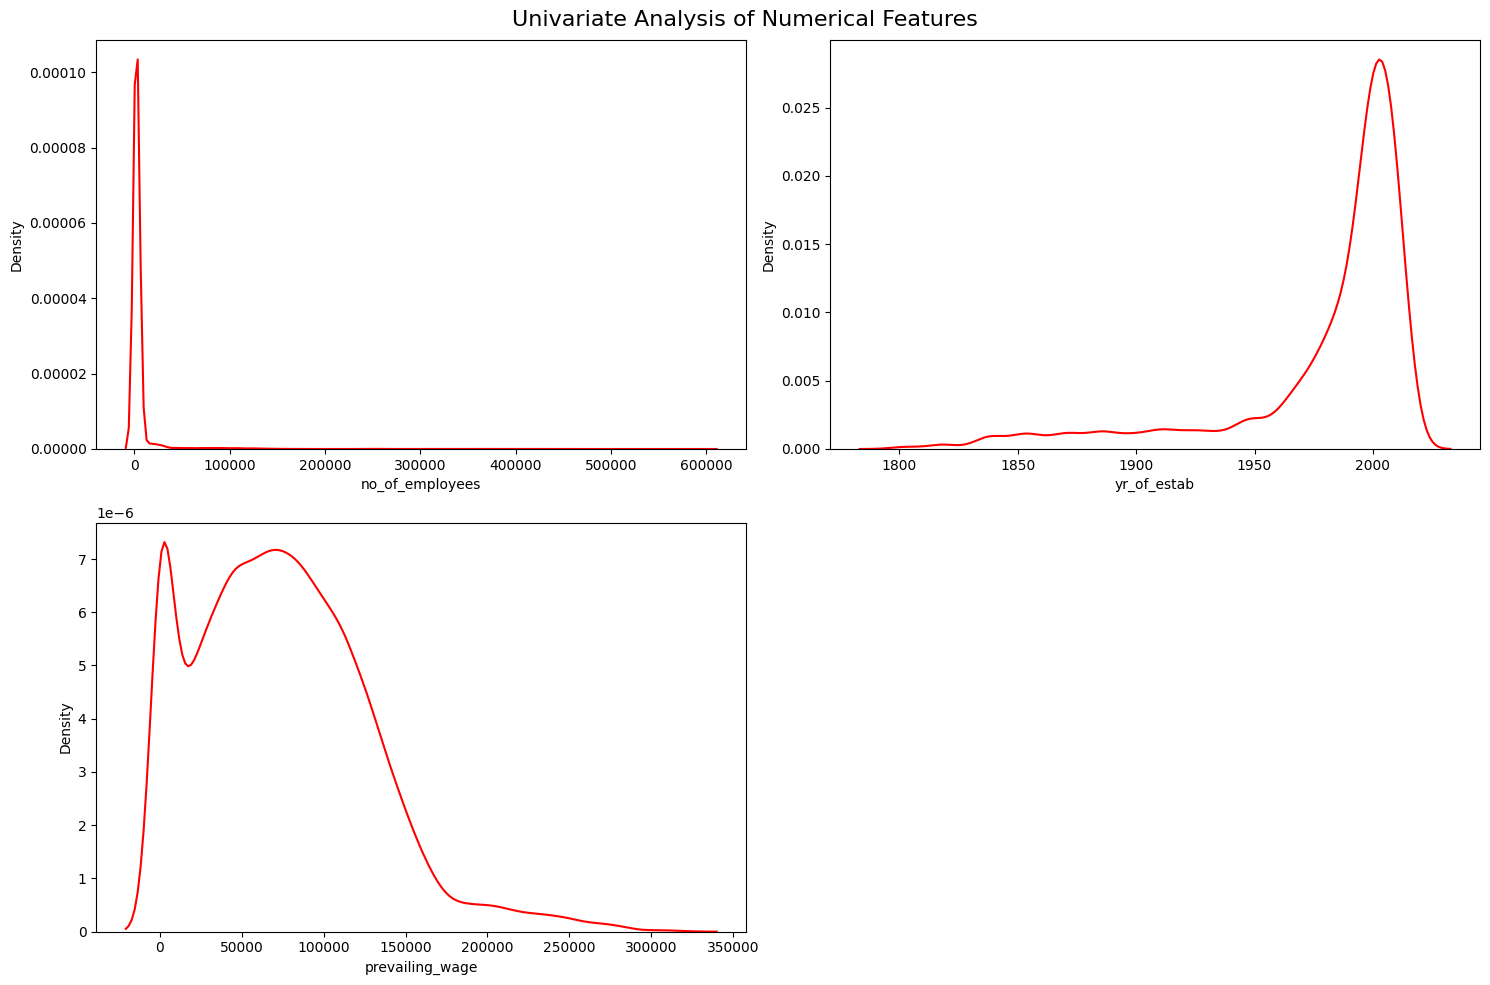

In [38]:
plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=16)

for i in range(0, len(numeric_features)):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(df[numeric_features[i]], color='red')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

In [ ]:
'''Insights from Univariate Analysis:'
1) no_of_employees is highly right-skewed → most companies are small, with a few very large organizations acting as outliers.
2) yr_of_estab is left-skewed → most organizations were established between 1990–2010, indicating dominance of relatively modern companies.
3) prevailing_wage shows multiple peaks → suggests different salary groups, possibly representing different job categories or skill levels.
4) no_of_employees and prevailing_wage contain outliers → log transformation or scaling may improve model performance.
5) yr_of_estab can be converted into company age → may provide better business insight and predictive power for ML models.

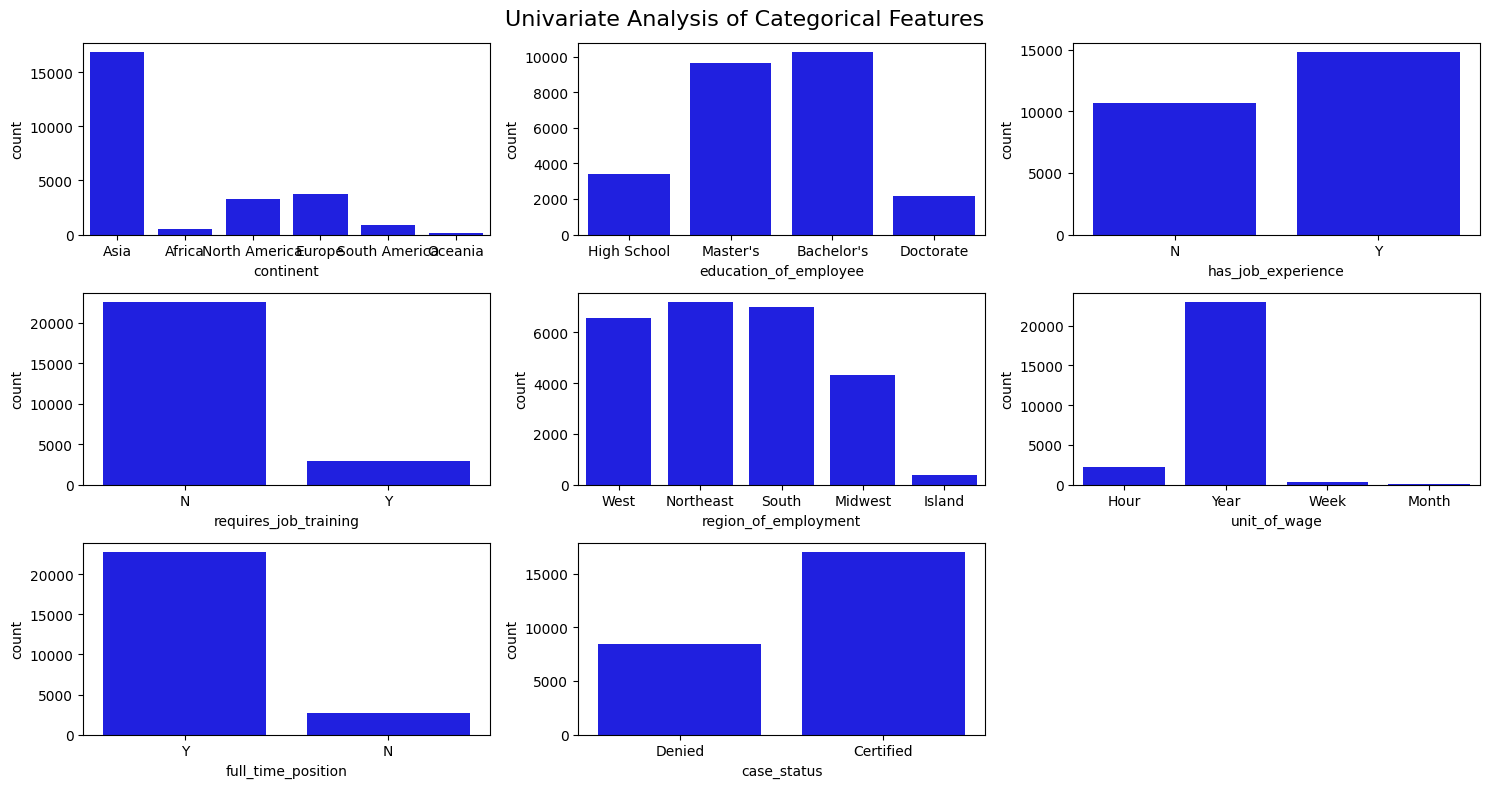

In [40]:
categorical_features.remove('case_id')
plt.figure(figsize=(15, 8))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=16)
for i in range(0, len(categorical_features)):
    plt.subplot(3, 3, i+1)
    sns.countplot(x=df[categorical_features[i]], color='blue')
    plt.xlabel(categorical_features[i])
    plt.tight_layout()

Multivariate Analysis

In [42]:
discrete_features=[feature for feature in numeric_features if len(df[feature].unique())<=25]
continuous_features=[feature for feature in numeric_features if len(df[feature].unique())>25]
print("we have {} discrete features : {}".format(len(discrete_features), discrete_features))
print("we have {} continuous features : {}".format(len(continuous_features), continuous_features))


we have 0 discrete features : []
we have 3 continuous features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


In [44]:
from scipy.stats import chi2_contingency
chi2_test = []

for feature in categorical_features:
    if chi2_contingency(pd.crosstab(df['case_status'], df[feature]))[1] < 0.05:
        chi2_test.append('reject Null Hypothesis')
    else:
        chi2_test.append('fail to reject Null Hypothesis')

result = pd.DataFrame(data=[categorical_features, chi2_test]).T
result.columns = ['Column', 'Hypothesis Result']

result

,Column,Hypothesis Result
0,continent,reject Null Hypothesis
1,education_of_employee,reject Null Hypothesis
2,has_job_experience,reject Null Hypothesis
3,requires_job_training,fail to reject Null Hypothesis
4,region_of_employment,reject Null Hypothesis
5,unit_of_wage,reject Null Hypothesis
6,full_time_position,reject Null Hypothesis
7,case_status,reject Null Hypothesis


here requires_job_training fails to reject null hypothesis so it doesnt correlate with target column!

In [45]:
df.isnull().sum()

case_id                   0
continent                 0
education_of_employee    10
has_job_experience        0
requires_job_training     0
no_of_employees           0
yr_of_estab               0
region_of_employment      0
prevailing_wage          30
unit_of_wage              0
full_time_position        0
case_status               0
dtype: int64

In [48]:
continuous_features=[feature for feature in numeric_features if len(df[feature].unique())>=10]
print('No. of continuous features :',continuous_features)

No. of continuous features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


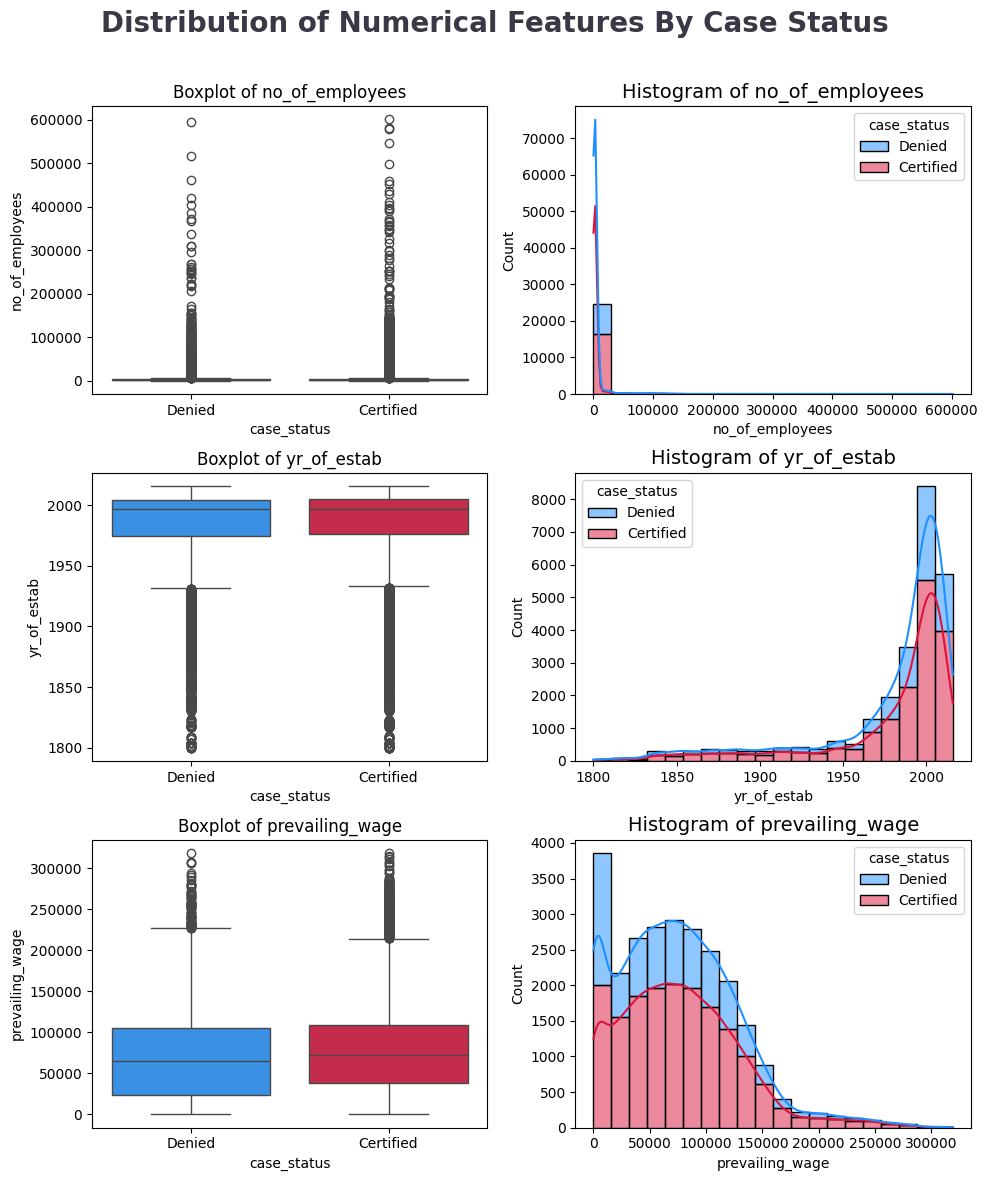

In [50]:
clri = ['#1E90FF', '#DC143C']
fig, ax = plt.subplots(3, 2, figsize=(10,12))
fig.suptitle("Distribution of Numerical Features By Case Status", color='#3C3744',fontsize=20,fontweight='bold',ha='center')
for i, col in enumerate(continuous_features):
    sns.boxplot(
        data=df,
        x='case_status',
        y=col,
        palette=clri,
        ax=ax[i,0]
    )

    ax[i,0].set_title(f'Boxplot of {col}', fontsize=12)

    sns.histplot(
        data=df,
        x=col,
        hue='case_status',
        bins=20,
        kde=True,
        multiple='stack',
        palette=clri,
        ax=ax[i,1]
    )

    ax[i,1].set_title(f'Histogram of {col}', fontsize=14)

fig.tight_layout()
fig.subplots_adjust(top=0.90)

In [ ]:
'''Initial Analysis Report
1. Distribution Analysis
no_of_employees: Extremely Right Skewed. Most companies are small, but extreme outliers (up to 600,000) exist. Requires log transformation to normalize.

yr_of_estab: Left Skewed. A high concentration of companies established post-2000. Outliers exist below the lower bound (older companies).

prevailing_wage: Right Skewed. Features a long tail with outliers above the upper bound. This appears to be a significant predictor, as denials are more frequent in lower wage brackets.

2. Data Quality & Cleaning
Missing Values: Present in the dataset. These must be handled via imputation (Median for numerical; Mode for categorical) before modeling.

Irrelevant Features: The case_id column will be dropped as it consists of unique identifiers that provide no predictive power.

Target Variable: The case_status column is confirmed as the target for Binary Classification.

3. Feature Engineering Plan
Outlier Management: Use the IQR (Interquartile Range) Method to cap extreme values in all numerical features to prevent model bias.

Transformation: Apply Log Transformation to no_of_employees and prevailing_wage to handle skewness and improve model convergence.

Encoding Strategy:

Binary Encoding: For categorical features with only two levels.

One-Hot Encoding: For multi-level categorical features (e.g., Region, Education) to convert them into a machine-readable format.

4. Initial Hypothesis
"The prevailing_wage and specific categorical markers (like Education/Experience) will be the strongest predictors of visa certification, whereas company age and size show high overlap between classes and may have lower individual predictive power."
'''

Visualization (target column)

([<matplotlib.patches.Wedge at 0x2a4e7dd2760>,
 [Text(-0.9504957517603639, -0.5536766437962692, 'Certified'),
  Text(1.036904403661537, 0.6040109747904524, 'Denied')],
 [Text(-0.5184522282329257, -0.30200544207069224, '66.79%'),
  Text(0.6048609021358965, 0.3523397352944306, '33.21%')])

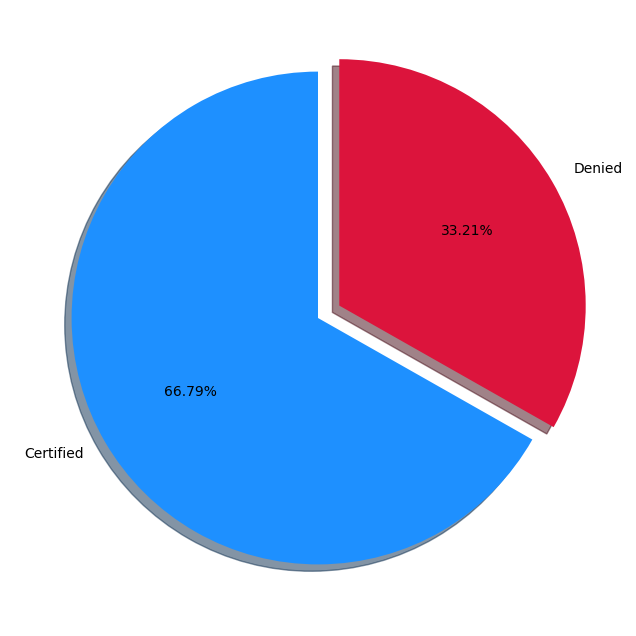

In [9]:
percentage=df.case_status.value_counts(normalize=True)*100
labels=['Certified', 'Denied']

fig, ax=plt.subplots(figsize=(15,8))
explode=(0,0.1)
ax.pie(percentage, labels=labels, startangle=90, autopct='%1.2f%%',shadow = True, explode=explode, colors=['#1E90FF', '#DC143C'])

-> imbalanced data!

In [10]:
df.groupby('continent')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
continent     case_status            
Africa        Certified     72.050817
              Denied        27.949183
Asia          Certified     65.310480
              Denied        34.689520
Europe        Certified     79.233655
              Denied        20.766345
North America Certified     61.877278
              Denied        38.122722
Oceania       Certified     63.541667
              Denied        36.458333
South America Certified     57.863850
              Denied        42.136150

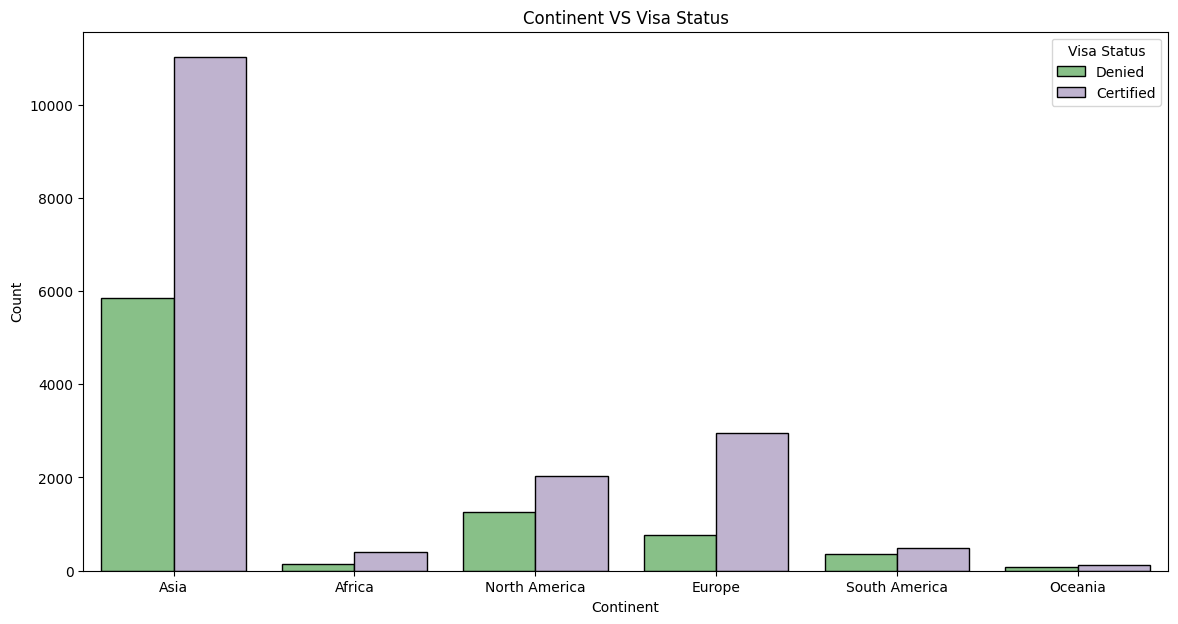

In [13]:
plt.subplots(figsize=(14,7))
sns.countplot(x='continent', hue='case_status', data=df, ec='black',palette='Accent')
plt.title('Continent VS Visa Status')
plt.xlabel('Continent')
plt.ylabel('Count')
plt.legend(title='Visa Status')

In [ ]:
'''Insights:
1) Asia has the highest number of applications and certifications, but also a significant denial rate, indicating a large volume of applicants with varying qualifications.
2) Europe and North America show higher certification rates compared to other continents, suggesting stronger applicant profiles or more favorable visa policies in these regions.
3) Dominant Volume: Asia is the primary source of applications, with a total volume that significantly exceeds all other continents combined.
4) High Success Ratios: Europe and Asia show the most favorable "Certified" to "Denied" ratios. Applicants from Europe, in particular, appear to have a very high likelihood of certification relative to denials.
5) Lower Representation: Oceania, South America, and Africa have the lowest number of applications, suggesting they represent a much smaller segment of the visa applicant pool.
'''

In [14]:
df.groupby('education_of_employee')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
education_of_employee case_status            
Bachelor's            Certified     62.238923
                      Denied        37.761077
Doctorate             Certified     87.299404
                      Denied        12.700596
High School           Denied        65.964912
                      Certified     34.035088
Master's              Certified     78.624130
                      Denied        21.375870

In [ ]:
'''Insights:
1) Higher Education Correlates with Certification: Applicants with a Master’s degree have the highest certification rate (~80%), followed by those with a Bachelor’s degree (~70%). This suggests that higher education levels significantly increase the likelihood of visa approval.
2) Lower Education Levels Show Higher Denial Rates: Applicants with only a High School education or less have significantly higher denial rates, indicating that lower educational attainment may be a major factor in visa rejections.
3) Education as a Key Predictor: The stark contrast in certification rates across education levels highlights education_of_employee as a critical feature for predictive modeling, likely serving as a strong indicator of applicant qualifications and visa approval chances.'''

In [15]:
df.groupby('has_job_experience')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
has_job_experience case_status            
N                  Certified     56.134108
                   Denied        43.865892
Y                  Certified     74.476422
                   Denied        25.523578

> more job experience, more likely to be certified

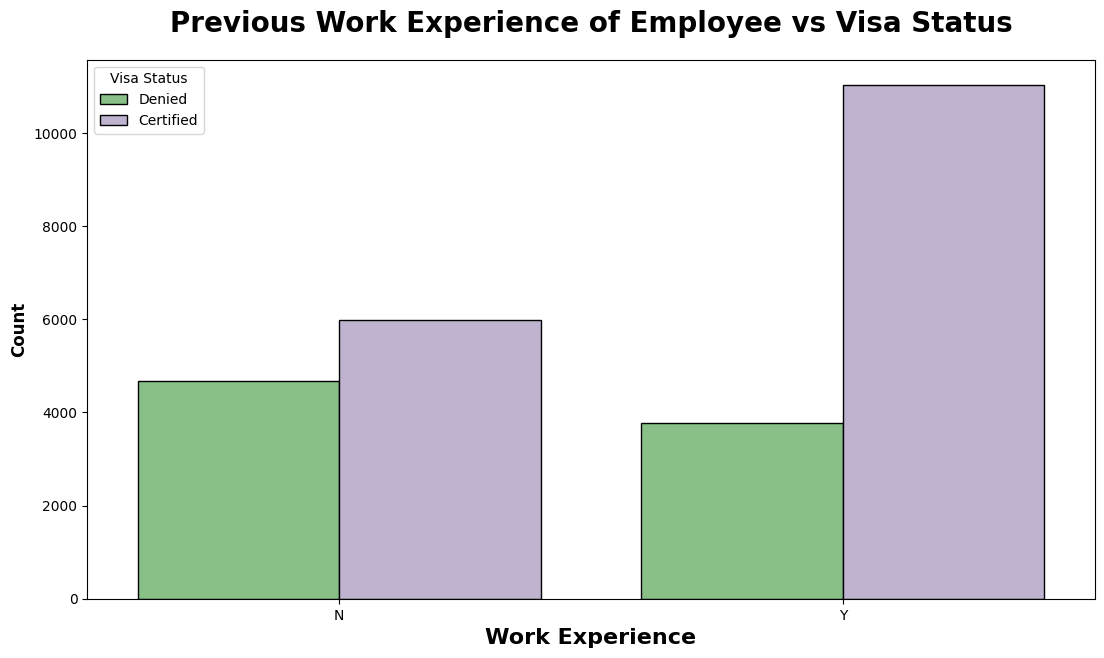

In [16]:
plt.subplots(figsize=(13,7))
sns.countplot(x='has_job_experience', hue='case_status', data=df, ec='black',palette='Accent')
plt.title('Previous Work Experience of Employee vs Visa Status',weight='bold',fontsize=20,pad=20)
plt.ylabel('Count',weight='bold', fontsize=12)
plt.xlabel('Work Experience',weight='bold', fontsize=16)
plt.legend(title='Visa Status')
plt.show()

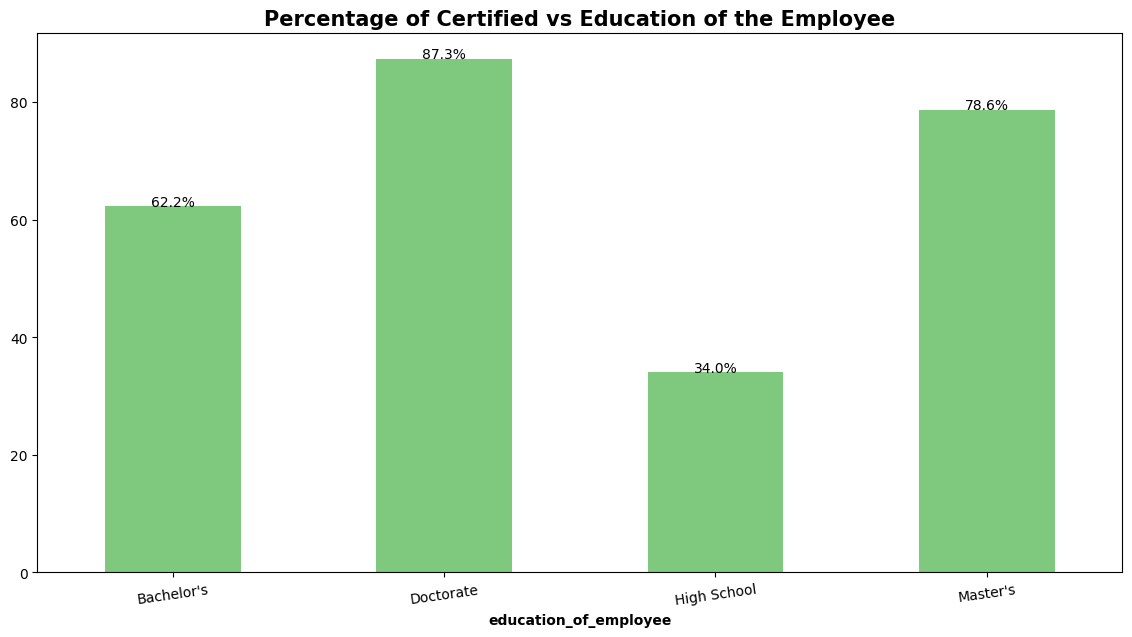

In [19]:
plt.figure(figsize=[14,7])

order1 = (
    100 * df[df["case_status"].isin(["Certified"])]["education_of_employee"].value_counts()
    / df["education_of_employee"].value_counts()
)

order1.plot(kind='bar', stacked=True, colormap="Accent")

plt.title(
    "Percentage of Certified vs Education of the Employee",
    fontsize=15,
    fontweight='bold'
)

for n in range(order1.shape[0]):
    count = order1.iloc[n]
    strt = "{:0.1f}%".format(count)
    plt.text(n, count + 0.1, strt, ha='center')

plt.xlabel('education_of_employee', fontweight='bold')
plt.xticks(rotation=8)
plt.show()

In [ ]:
'''Insights:
1) Higher Education Correlates with Certification: Applicants with a Master’s degree have the highest certification rate (~80%), followed by those with a Bachelor’s degree (~70%). This suggests that higher education levels significantly increase the likelihood of visa approval.
2) Lower Education Levels Show Higher Denial Rates: Applicants with only a High School education or less have significantly higher denial rates, indicating that lower educational attainment may be a major factor in visa rejections.
3) Education as a Key Predictor: The stark contrast in certification rates across education levels highlights education_of_employee as a critical feature for predictive modeling, likely serving as a strong indicator of applicant qualifications and visa approval chances.'''

'Insights:'

In [22]:
df.groupby('has_job_experience')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
has_job_experience case_status            
N                  Certified     56.134108
                   Denied        43.865892
Y                  Certified     74.476422
                   Denied        25.523578

In [ ]:
'''job experience is a strong predictor of visa certification, with applicants having prior work experience showing significantly higher approval rates compared to those without experience. This suggests that employers and visa authorities place considerable value on practical experience, likely viewing it as an indicator of an applicant's ability to perform the job effectively and contribute to the workforce.'''

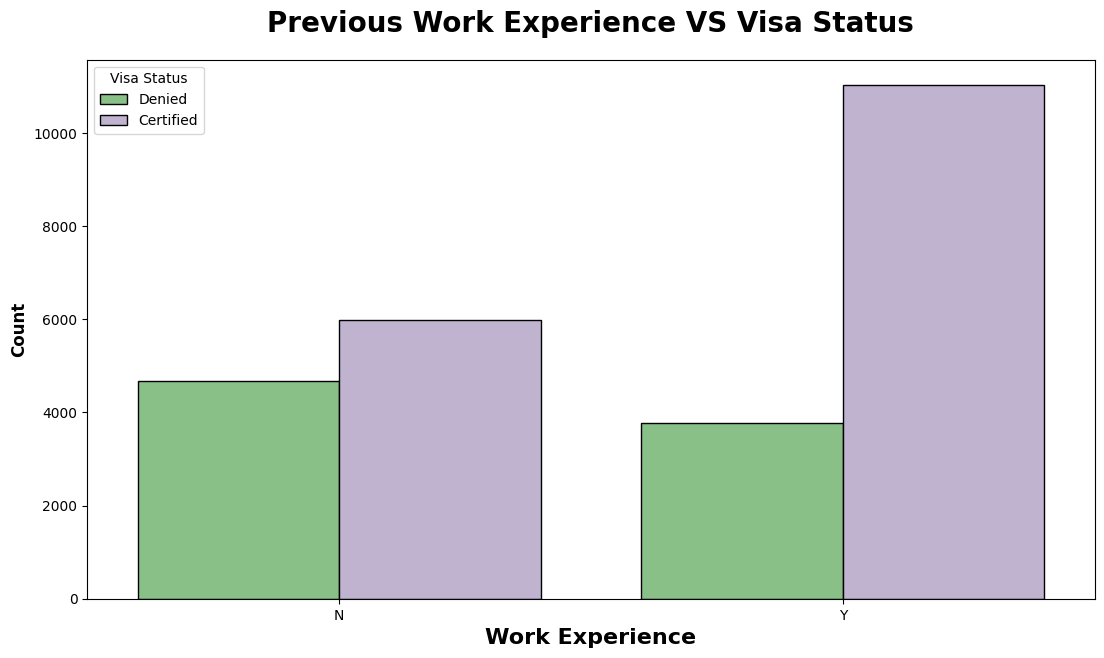

In [23]:
plt.subplots(figsize=(13,7))
sns.countplot(x='has_job_experience', hue='case_status', data=df, ec='black',palette='Accent')
plt.title('Previous Work Experience VS Visa Status',weight='bold',fontsize=20,pad=20)
plt.ylabel('Count',weight='bold', fontsize=12)
plt.xlabel('Work Experience',weight='bold', fontsize=16)
plt.legend(title='Visa Status')
plt.show()

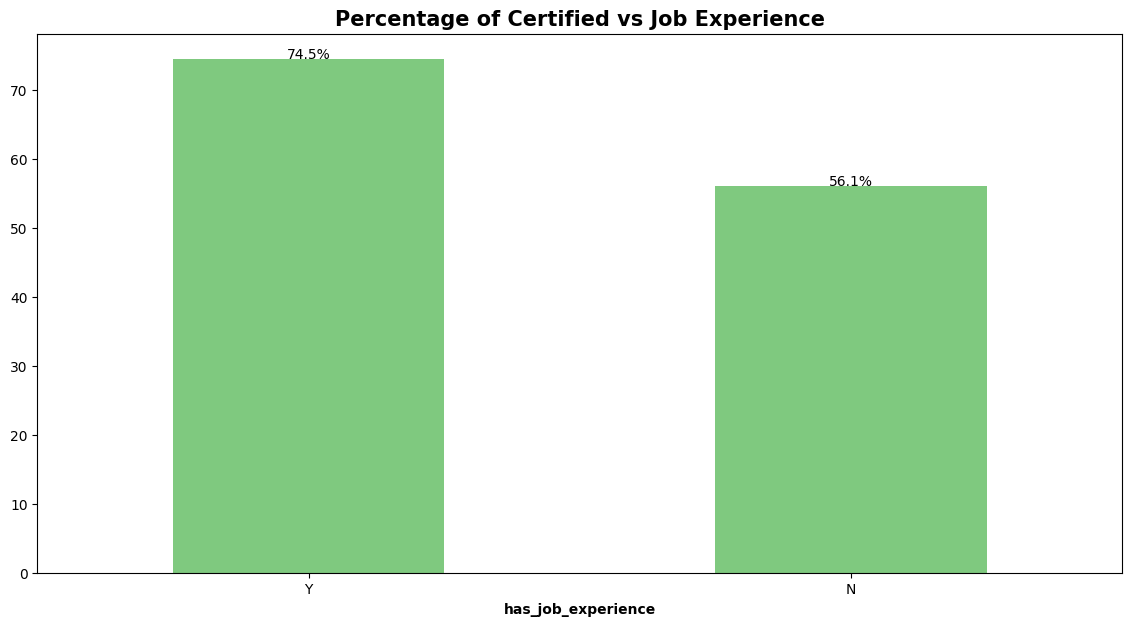

In [24]:
plt.figure(figsize=[14,7])

order1 = (
    100 * df[df["case_status"].isin(["Certified"])]["has_job_experience"].value_counts()
    / df["has_job_experience"].value_counts()
)

order1.plot(kind='bar', stacked=True, colormap='Accent')

plt.title(
    "Percentage of Certified vs Job Experience",
    fontsize=15,
    fontweight='bold'
)

for n in range(order1.shape[0]):
    count = order1.iloc[n]
    strt = "{:0.1f}%".format(count)

    plt.text(n, count + 0.1, strt, ha='center')

plt.xlabel("has_job_experience", fontweight='bold')
plt.xticks(rotation=0)

plt.show()

In [ ]:
'''Insights:
1) Significant Advantage for Experienced Candidates: There is a notable difference in the certification success rate based on professional history. Applicants with prior job experience (Y) have a certification rate of 74.5%.
2) Lower Success for Entry-Level Applicants: Applicants without prior job experience (N) show a significantly lower certification rate of 56.1%.
'''

In [25]:
df.groupby('requires_job_training')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
requires_job_training case_status            
N                     Certified     66.645949
                      Denied        33.354051
Y                     Certified     67.884941
                      Denied        32.115059

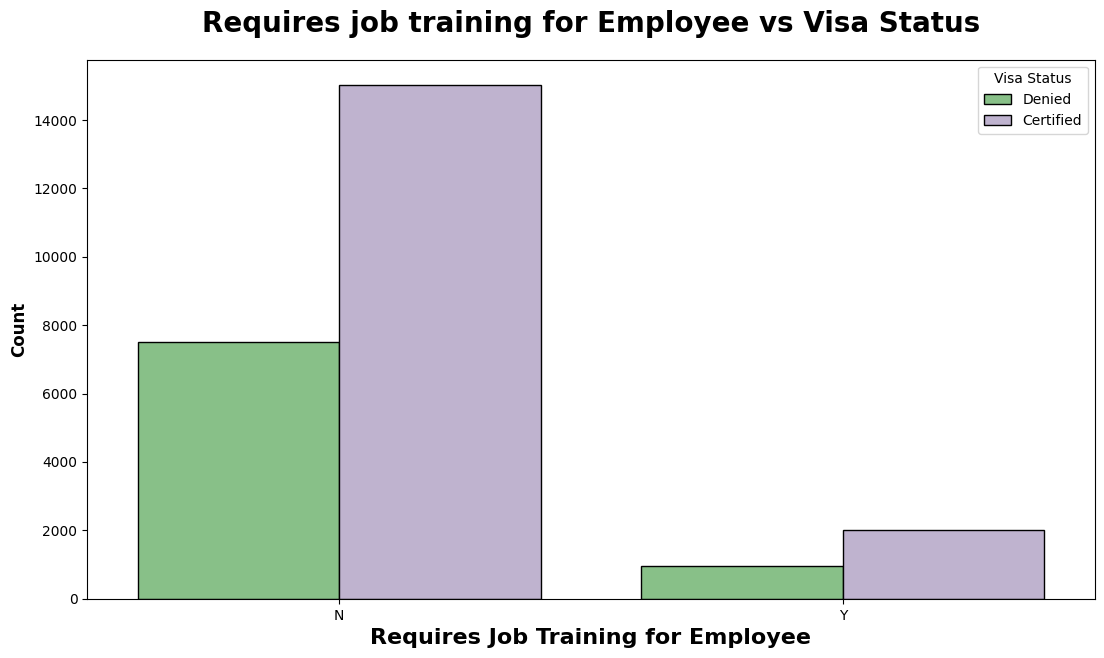

In [29]:
plt.subplots(figsize=(13,7))
sns.countplot(x="requires_job_training", hue="case_status", data=df, ec="black", palette="Accent")
plt.title("Requires job training for Employee vs Visa Status", weight="bold", fontsize=20, pad=20) 
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Requires Job Training for Employee", weight="bold", fontsize=16)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

In [ ]:
'''Insights:
job training requirement appears to be a significant factor in visa certification, with applicants whose positions do not require job training showing higher approval rates compared to those that do. This suggests that employers and visa authorities may prefer candidates who are already skilled and can contribute immediately, while positions requiring training may be viewed as less favorable for sponsorship.'''

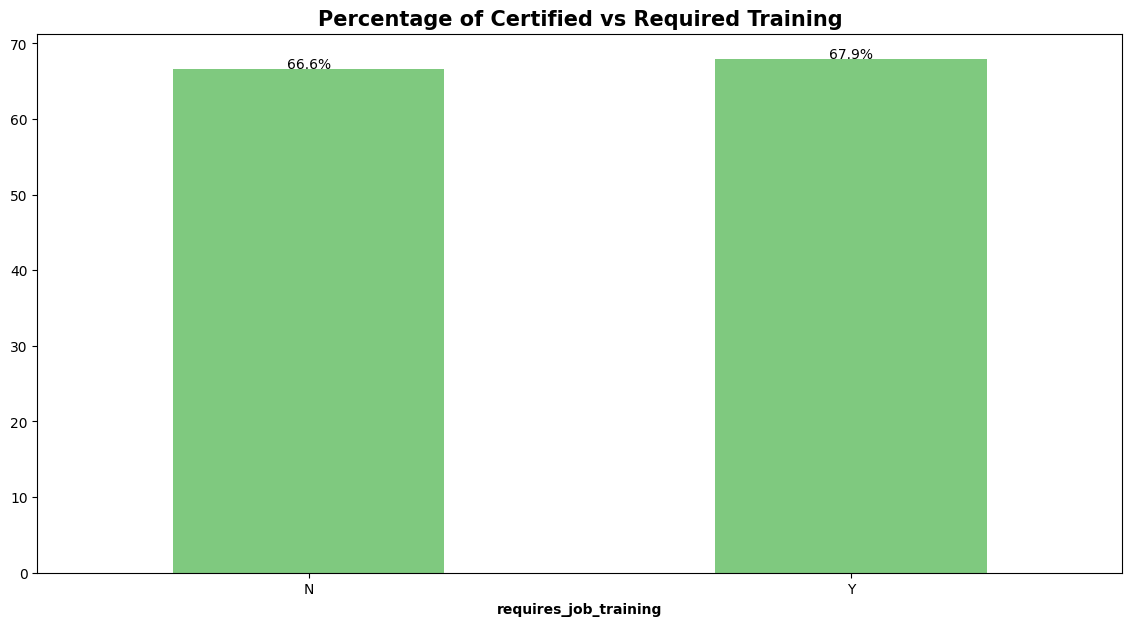

In [30]:
plt.figure(figsize=[14,7])

order1 = (
    100 * df[df["case_status"].isin(["Certified"])]["requires_job_training"].value_counts()
    / df["requires_job_training"].value_counts()
)

order1.plot(kind='bar', stacked=True, colormap="Accent")

plt.title(
    "Percentage of Certified vs Required Training",
    fontsize=15,
    fontweight='bold'
)

for n in range(order1.shape[0]):
    count = order1.iloc[n]
    strt = "{:0.1f}%".format(count)

    plt.text(n, count + 0.1, strt, ha='center')

plt.xlabel('requires_job_training', fontweight='bold')
plt.xticks(rotation=0)

plt.show()

Negligible Impact: Whether a job requires specific training (Y) or not (N) appears to have almost no influence on the visa certification rate.

Uniform Success Rates: The certification rate for jobs requiring training is 67.9%, while for those not requiring it, the rate is 66.6%. The minor difference of 1.3% suggests that this feature is not a strong discriminator on its own.

Predictive Value: In isolation, requires_job_training is likely a low-importance feature for your machine learning model.

C:\Users\chandra\AppData\Local\Temp\ipykernel_16740\1382975819.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


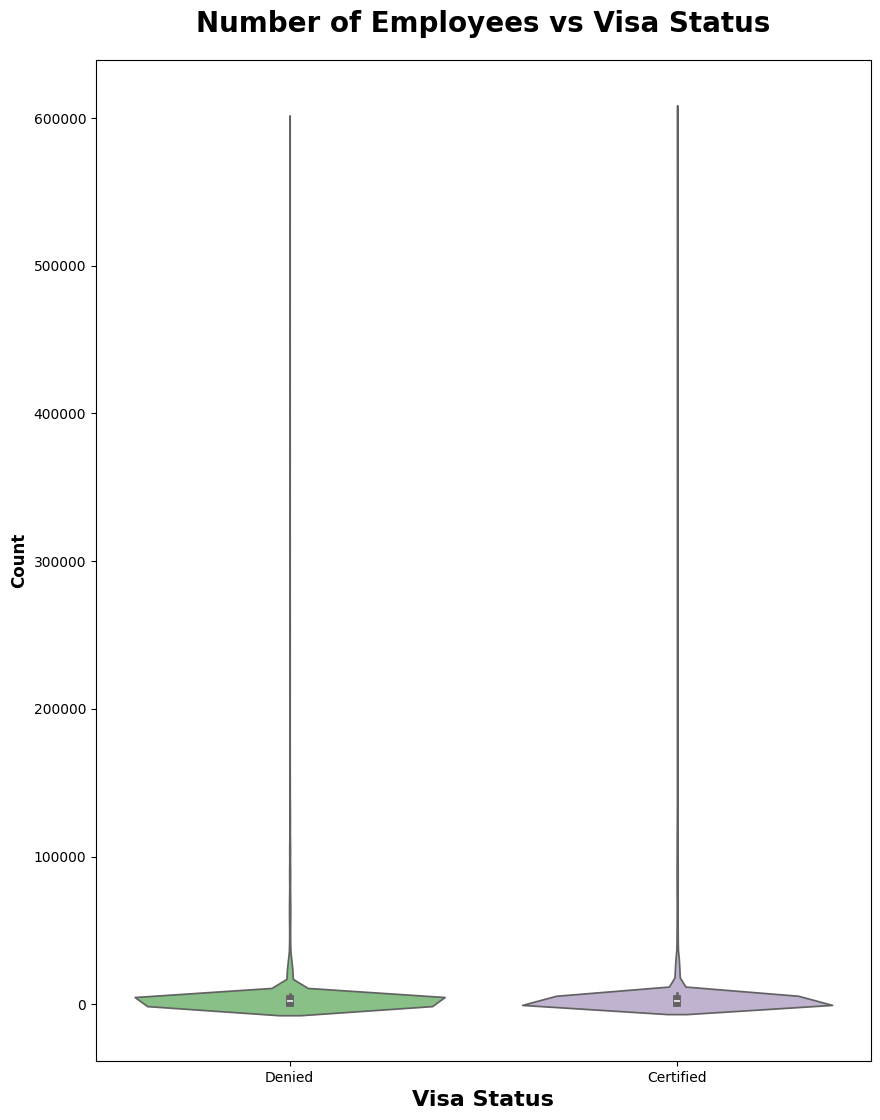

In [31]:
plt.subplots(figsize=(10,13))

sns.violinplot(
    x="case_status",
    y="no_of_employees",
    data=df,
    palette="Accent"
)

plt.title(
    "Number of Employees vs Visa Status",
    weight="bold",
    fontsize=20,
    pad=20
)

plt.ylabel("Count", weight="bold", fontsize=12)

plt.xlabel(
    "Visa Status",
    weight="bold",
    fontsize=16
)

plt.show()

In [ ]:
'''Insights:
1) Number of Employees Shows High Variability: Both certified and denied applications span a wide range of company sizes, from very small to very large organizations, indicating that company size alone is not a strong predictor of visa certification.
2) Overlapping Distributions: The distributions of company sizes for certified and denied applications overlap significantly, suggesting that other factors (like education, experience, or wage) may play a more decisive role in visa outcomes than company size.
3) Outliers Present: Both groups contain outliers with extremely high employee counts, which may skew analysis and should be addressed in data preprocessing for modeling.'''

In [32]:
df.groupby('unit_of_wage')['case_status'].value_counts(normalize=True)

unit_of_wage  case_status
Hour          Denied         0.653686
              Certified      0.346314
Month         Certified      0.617978
              Denied         0.382022
Week          Certified      0.621324
              Denied         0.378676
Year          Certified      0.698850
              Denied         0.301150
Name: proportion, dtype: float64

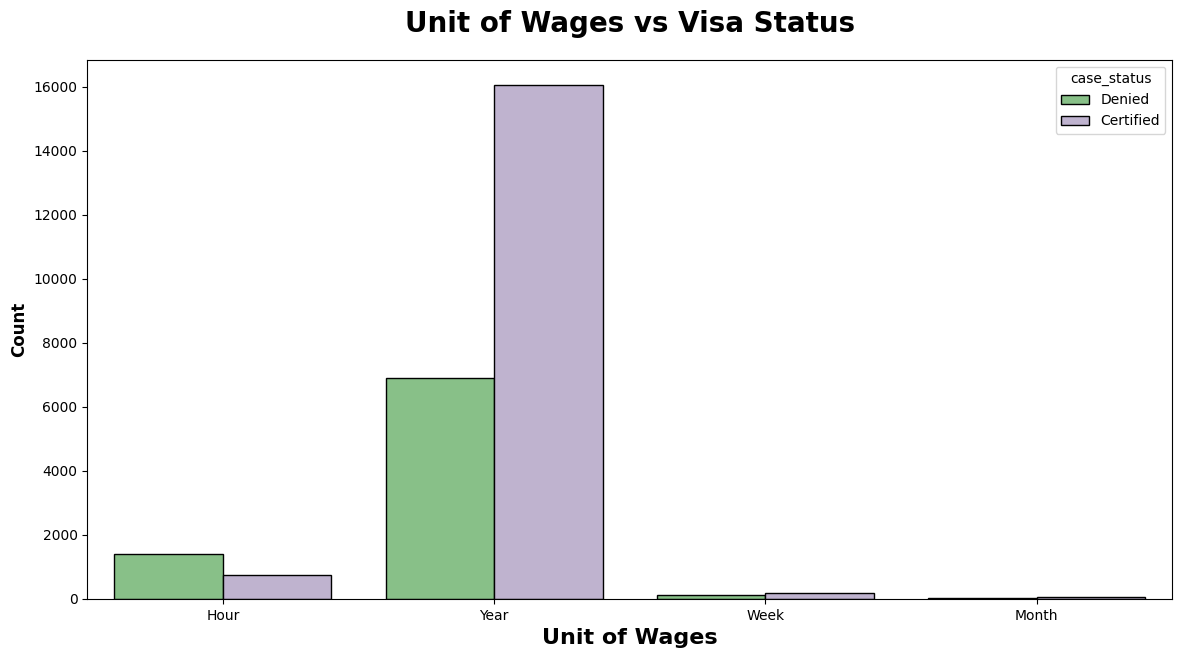

In [35]:
plt.subplots(figsize=(14,7))
sns.countplot(x='unit_of_wage', hue='case_status', data=df, ec='black', palette='Accent')
plt.title('Unit of Wages vs Visa Status', weight='bold', fontsize=20, pad=20)
plt.xlabel('Unit of Wages', weight='bold', fontsize=16)
plt.ylabel('Count', weight='bold', fontsize=12)
plt.show()

In [ ]:
'''Insights:
1) Yearly Wage Dominance: The Year category represents the overwhelming majority of applications and maintains the highest volume of Certified statuses. This reflects the standard for full-time professional sponsorship.
2) Hourly Wage Risk: The Hour category is the only unit where Denied cases exceed Certified cases. Hourly roles appear to be under much higher regulatory scrutiny.
3) Low Volume Categories: Weekly and Monthly wage units are rare in this dataset, indicating they are unconventional pay structures for visa-sponsored positions.
4) High Predictive Value: The stark contrast in success rates between "Year" and "Hour" units makes this a critical feature for model accuracy.'''

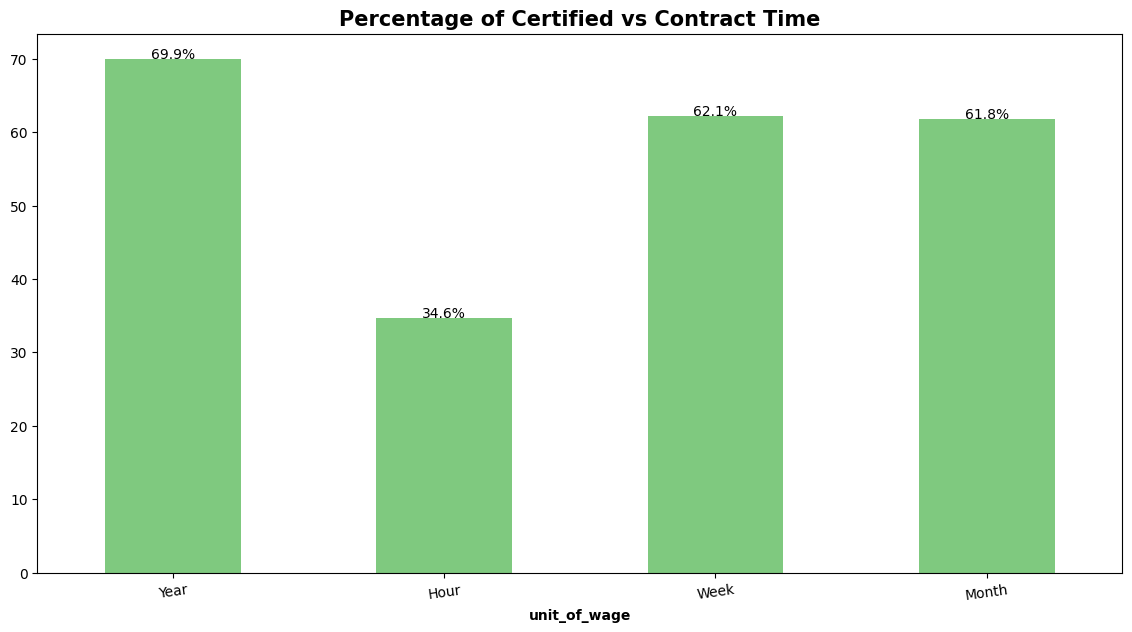

In [36]:
plt.figure(figsize=[14,7])

order1 = (
    100 * df[df["case_status"].isin(["Certified"])]["unit_of_wage"].value_counts()
    / df["unit_of_wage"].value_counts()
)

order1.plot(kind='bar', stacked=True, colormap='Accent')

plt.title(
    "Percentage of Certified vs Contract Time",
    fontsize=15,
    fontweight='bold'
)

for n in range(order1.shape[0]):
    count = order1.iloc[n]
    strt = "{:0.1f}%".format(count)

    plt.text(n, count + 0.1, strt, ha='center')

plt.xlabel('unit_of_wage', fontweight="bold")
plt.xticks(rotation=8)

plt.show()

1. Yearly Wages Yield Highest Certification
Workers paid on a Yearly basis have the highest probability of being certified, at 69.9%. This suggests that salaried or long-term contract positions are much more likely to meet certification requirements than other wage structures.

2. Hourly Wages are a Significant Outlier
There is a massive drop in certification for those paid by the Hour, which stands at only 34.6%. This is nearly half the rate of yearly-paid workers. This could indicate that hourly roles are more likely to be entry-level, seasonal, or part-time positions where formal certification is either not required or harder to obtain.

3. Consistency Across Week and Month
The certification rates for Weekly (62.1%) and Monthly (61.8%) units are nearly identical. This suggests that once a contract moves away from hourly pay into these fixed intervals, the likelihood of certification stabilizes at a relatively high level (approx. 62%).

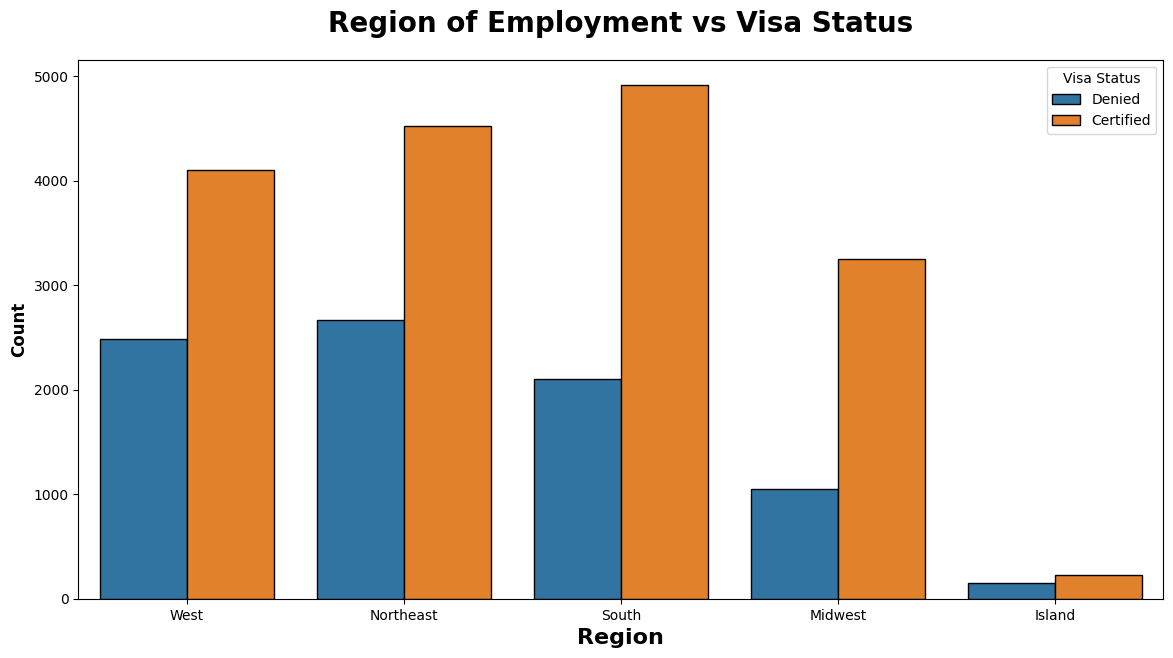

In [37]:
plt.subplots(figsize=(14,7))

sns.countplot(
    x="region_of_employment",
    hue="case_status",
    data=df,
    ec='k'
)

plt.title(
    "Region of Employment vs Visa Status",
    weight="bold",
    fontsize=20,
    pad=20
)

plt.xlabel("Region", weight="bold", fontsize=16)

plt.ylabel("Count", weight="bold", fontsize=12)

plt.legend(title="Visa Status", fancybox=True)

plt.show()

In [ ]:
'''Insights:
1) Top Performer: The South has the highest overall volume and the most certifications (nearly 5,000).
2) Highest Efficiency: The Midwest boasts the best approval ratio, with certifications being roughly triple the number of denials.
3) Highest Friction: The Northeast and West experience the highest volumes of denials, suggesting more competitive or rigorous application pools.
4) Low Volume: Island regions represent a negligible fraction of the total data.'''

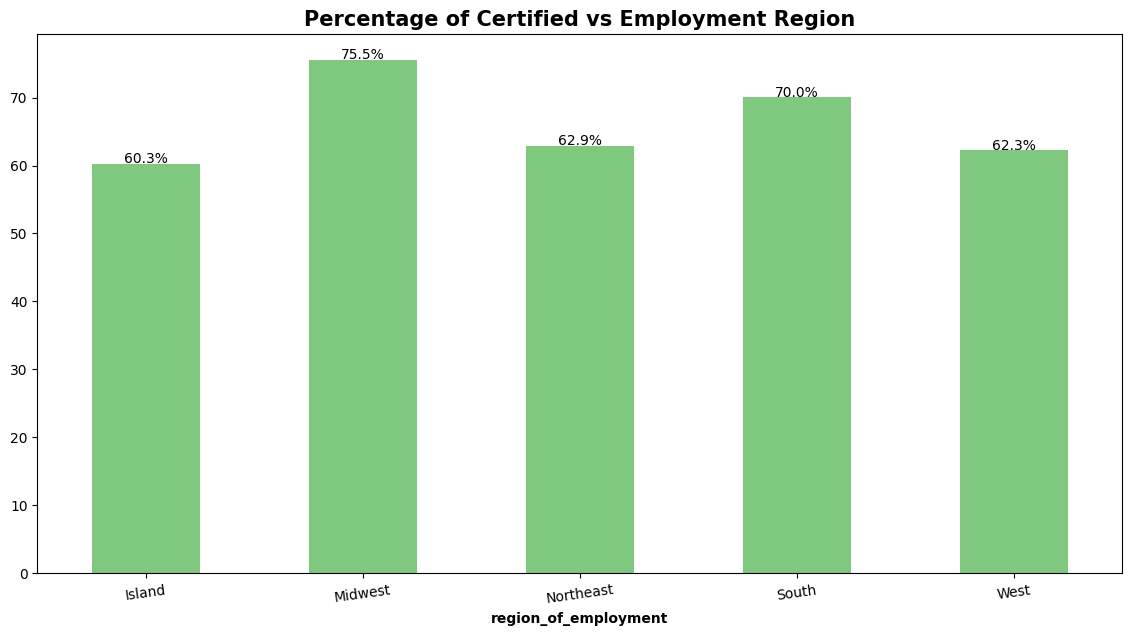

In [38]:
plt.figure(figsize=[14,7])
order1 = (
    100 * df[df["case_status"].isin(["Certified"])]["region_of_employment"].value_counts()
    / df["region_of_employment"].value_counts()
)
order1.plot(kind='bar', stacked=True, colormap="Accent")
plt.title(
    "Percentage of Certified vs Employment Region",
    fontsize=15,
    fontweight='bold'
)
for n in range(order1.shape[0]):
    count = order1.iloc[n]
    strt = "{:0.1f}%".format(count)

    plt.text(n, count + 0.1, strt, ha='center')

plt.xlabel('region_of_employment', fontweight='bold')
plt.xticks(rotation=8)
plt.show()

In [ ]:
'''Insights:
1) Overall High Approval: All regions maintain a strong baseline, with certification rates consistently exceeding 60%.
2) Midwest Dominance: The Midwest is the top performer with a 75.5% certification rate, outperforming the lowest region by over 15%.
3) Secondary Success in the South: The South follows with a solid 70.0% rate, proving to be a reliable region for high-volume approvals.
4) Coastal Parity: The Northeast (62.9%) and West (62.3%) show nearly identical success rates, likely due to the high volume and competitive nature of tech and finance hubs in these areas.
5) Island Baseline: The Island region has the lowest certification rate at 60.3%, yet still maintains a majority approval status.
6) Regional Correlation: The data suggests a clear "Midwest Advantage," where applicants face a significantly higher probability of approval compared to coastal or island regions.'''

In [39]:
df.groupby('prevailing_wage').case_status.value_counts()

prevailing_wage  case_status
2.1367           Certified      1
2.9561           Denied         1
3.0031           Denied         1
3.3188           Denied         1
3.4889           Certified      1
                               ..
311734.4900      Certified      1
314156.0600      Certified      1
315497.6000      Certified      1
318446.0500      Certified      1
319210.2700      Denied         1
Name: count, Length: 25404, dtype: int64

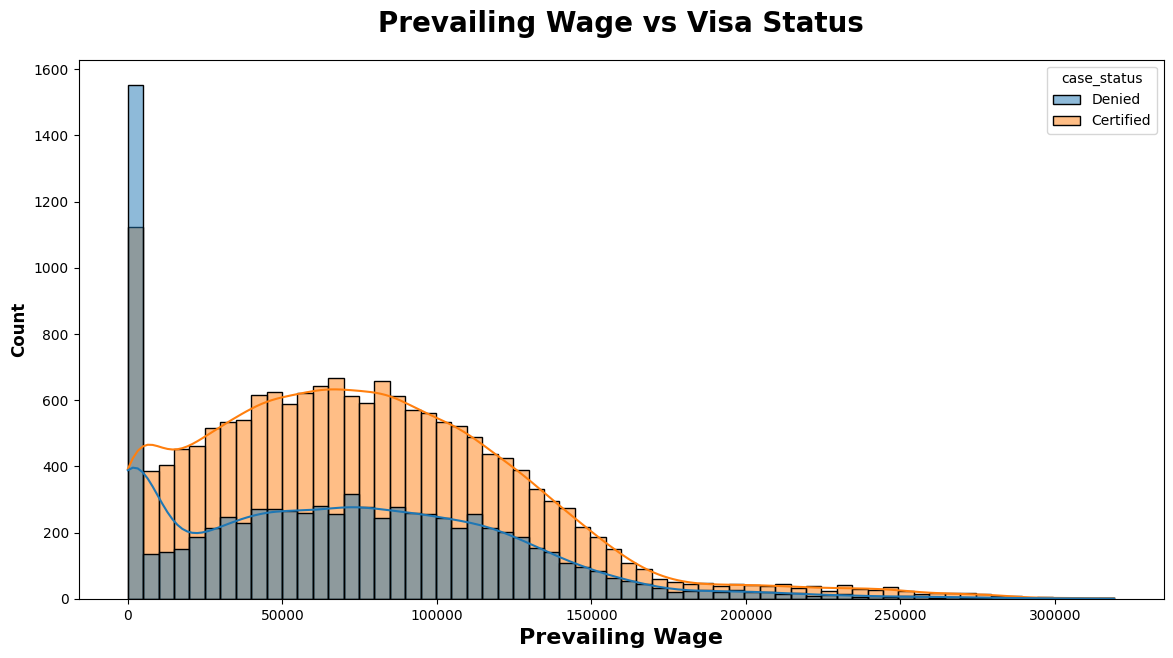

In [40]:
plt.subplots(figsize=(14,7))

sns.histplot(
    x="prevailing_wage",
    hue="case_status",
    data=df,
    kde=True
)

plt.title(
    "Prevailing Wage vs Visa Status",
    weight="bold",
    fontsize=20,
    pad=20
)

plt.xlabel("Prevailing Wage", weight="bold", fontsize=16)

plt.ylabel("Count", weight="bold", fontsize=12)

plt.show()

In [ ]:
'''Insights:
1) Certification peaks significantly between $50,000 and $100,000, showing mid-range salaries have the highest approval volume. 
2) Conversely, applications with near-zero wages see a massive spike in both filings and denials, while high-salary roles ($150k+) are rare but consistently certified.'''

In [42]:
df.groupby('education_of_employee')['prevailing_wage'].mean().to_frame().sort_values(by='prevailing_wage', ascending=False)


,prevailing_wage
education_of_employee,
Master's,78856.085402
Bachelor's,73386.621092
High School,71580.203585
Doctorate,64674.272754


C:\Users\chandra\AppData\Local\Temp\ipykernel_16740\3695602524.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


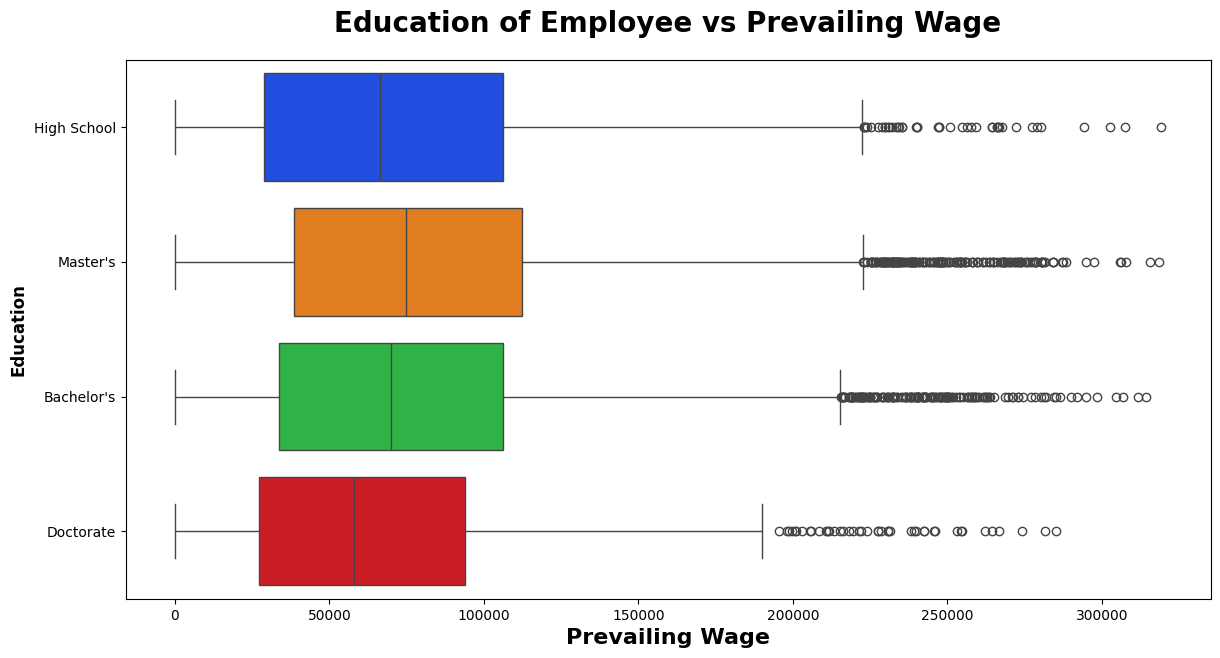

In [43]:
plt.subplots(figsize=(14,7))

sns.boxplot(
    y="education_of_employee",
    x="prevailing_wage",
    data=df,
    palette='bright'
)

plt.title(
    "Education of Employee vs Prevailing Wage",
    weight="bold",
    fontsize=20,
    pad=20
)

plt.xlabel("Prevailing Wage", weight="bold", fontsize=16)

plt.ylabel("Education", weight="bold", fontsize=12)

plt.show()

In [ ]:
'''Insights
1) Unexpected Medians: Master's and High School levels lead with the highest median wages (~$75,000), while Doctorate holders surprisingly have the lowest (~$60,000).
2) High School Outliers: Despite the lower entry requirement, the High School category features some of the highest individual earners in the dataset, exceeding $300,000.
3) Doctorate Stability: The Doctorate group has the most compact wage range and the fewest extreme outliers, indicating more standardized, predictable pay scales.
4) Broad Overlap: Education is not a strict predictor of income; there is massive overlap, meaning high performers with "lower" education often out-earn those with advanced degrees.
5) Bachelor’s vs. Master’s: Both follow very similar distributions, though a Master’s degree provides a slight "upper-hand" in the 75th percentile bracket.'''

In [44]:
print('Median Prevailing wage based on Job experience')
df.groupby('has_job_experience')['prevailing_wage'].median().to_frame().sort_values(by='prevailing_wage', ascending=False)

Median Prevailing wage based on Job experience


,prevailing_wage
has_job_experience,
N,72635.23
Y,69121.75


In [ ]:
'''Report:
1) Applicants without job experience have a slightly higher median prevailing wage (~72.6K) compared to applicants with job experience (~69.1K).
2) This suggests that salary offered is not strictly dependent on prior job experience in this dataset.
3) The difference is relatively small, indicating job experience may have limited impact on median wage levels.
4) Other factors such as education, job role, or region may influence wages more strongly.'''

In [45]:
print("Average Prevailing wage based on Continent")
df.groupby('continent')['prevailing_wage'].mean().to_frame().sort_values(by='prevailing_wage', ascending=False)


Average Prevailing wage based on Continent


,prevailing_wage
continent,
Asia,79557.069353
Africa,77551.827574
Oceania,75994.276719
North America,68058.741791
South America,60130.537331
Europe,59830.444650


C:\Users\chandra\AppData\Local\Temp\ipykernel_16740\962666206.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


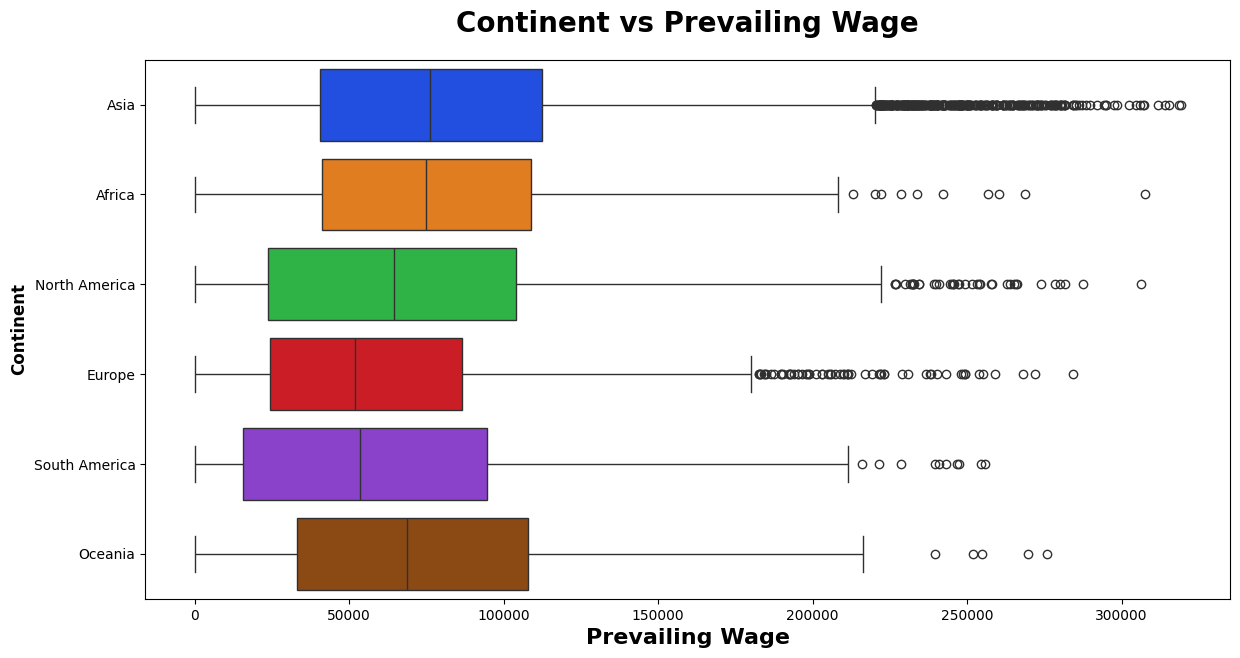

In [46]:
plt.subplots(figsize=(14,7))

sns.boxplot(
    y="continent",
    x="prevailing_wage",
    data=df,
    palette='bright'
)

plt.title(
    "Continent vs Prevailing Wage",
    weight="bold",
    fontsize=20,
    pad=20
)

plt.xlabel("Prevailing Wage", weight="bold", fontsize=16)

plt.ylabel("Continent", weight="bold", fontsize=12)

plt.show()

In [ ]:
'''Insights:
1) Asia and Africa have the highest median prevailing wages (~$75K).
2) Asia has the largest number of very high salary outliers ($220K–$320K).
3) Europe shows a narrower salary range with fewer high-end outliers.
4) South America, Oceania, and North America have similar mid-range median wages (~$55K–$65K).
5) Low-paying roles are present across all continents.'''

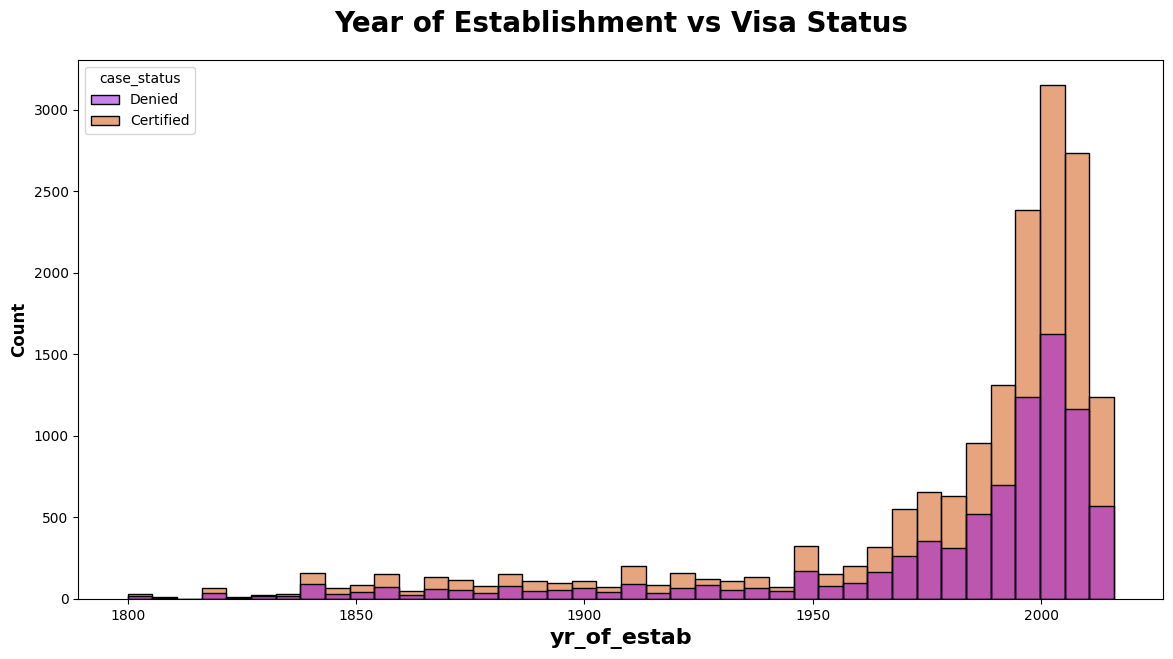

In [47]:
plt.subplots(figsize=(14,7))

sns.histplot(
    x="yr_of_estab",
    data=df,
    palette='gnuplot',
    bins=40,
    hue='case_status'
)

plt.title(
    "Year of Establishment vs Visa Status",
    weight="bold",
    fontsize=20,
    pad=20
)

plt.xlabel("yr_of_estab", weight="bold", fontsize=16)

plt.ylabel("Count", weight="bold", fontsize=12)

plt.show()

In [ ]:
'''Insights:
* Each bin represents a 5-year interval of company establishment.
* Most companies in the dataset were established after 2000.
* The highest number of companies were established between 2000–2005.
* The graph compares company establishment year with visa approval status to analyze whether company age influences certification rates.
* Color separation by `case_status` helps compare certified and denied applications over time.
'''

In [51]:
'''
Final Report:                                
1) Drop case_id as it is only an identifier.
2) Drop requires_job_training due to low impact on target variable.
3) Handle outliers in no_of_employees and prevailing_wage.
5) Group low-frequency categories in continent as "Others".
6) Handle imbalance in case_status before model building.'''

'\nFinal Report:                                \n1) Drop case_id as it is only an identifier.\n2) Drop requires_job_training due to low impact on target variable.\n3) Handle outliers in no_of_employees and prevailing_wage.\n5) Group low-frequency categories in continent as "Others".\n6) Handle imbalance in case_status before model building.'